<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML321ENSkillsNetwork817-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Content-based Course Recommender System using Course Similarities**


Estimated time needed: **45** minutes


## **Introduction**

In lab 6.1.3, we learned how to represent course descriptions using Bag of Words (BoW) features and how to compute the similarity between two courses based on their content. For example, two courses may be considered similar if their descriptions contain many of the same words or belong to similar genres. 

The similarity between course1 `Machine Learning for Everyone` and course2 `Machine Learning for Beginners` are `75%` as shown below.

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/module_2/images/course_sim.png)


In a content-based recommender system, recommendations are generated by comparing the content of items. If two courses are similar, then a user who likes one course may also like the other.

In this lab, we will use a course similarity matrix, which stores the similarity score between every pair of courses. Using this similarity matrix, we can recommend new courses to a user by finding courses that are similar to the courses the user has already enrolled in.

The main idea of this lab is:

- We already have similarity scores between courses
- We know which courses a user has taken
- We recommend new courses that are most similar to those courses

This lab does not build a new model.
Instead, it uses the existing similarity matrix to generate recommendations.

## **Objectives**


* Obtain the similarity between courses from a course similarity matrix
* Use the course similarity matrix to find and recommend new courses which are similar to enrolled courses


----


### **Prepare and setup lab environment**


Let's first install and import the required libraries:


In [1]:
#!pip install seaborn
#!pip install numpy
#!pip install pandas
#!pip install matplotlib

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline

In [3]:
# also set a random state
rs = 123

### **Load course similarity matrix**

Next, let's load a pre-made course similarity matrix. Such a similarity matrix could be easily calculated  by iterating through all possible course pairs and calculating their similarities.


In [4]:
sim_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/sim.csv"

In [5]:
sim_df = pd.read_csv(sim_url)
sim_df

,0,1,2,3,4,5,6,7,8,9,...,297,298,299,300,301,302,303,304,305,306
0,1.000000,0.088889,0.088475,0.065556,0.048810,0.104685,0.065202,0.143346,0.000000,0.024405,...,0.012695,0.070225,0.058224,0.046610,0.025850,0.033944,0.076825,0.072898,0.039276,0.121113
1,0.088889,1.000000,0.055202,0.057264,0.012182,0.078379,0.032545,0.119251,0.044162,0.000000,...,0.180593,0.124631,0.087187,0.093060,0.019354,0.028239,0.063911,0.138270,0.031367,0.076940
2,0.088475,0.055202,1.000000,0.026463,0.039406,0.000000,0.000000,0.154303,0.000000,0.000000,...,0.040996,0.037796,0.013430,0.037630,0.000000,0.018270,0.082698,0.133400,0.012684,0.000000
3,0.065556,0.057264,0.026463,1.000000,0.000000,0.250490,0.390038,0.000000,0.000000,0.000000,...,0.151882,0.420084,0.427908,0.055764,0.000000,0.094759,0.030638,0.017443,0.018796,0.158073
4,0.048810,0.012182,0.039406,0.000000,1.000000,0.000000,0.000000,0.085126,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.096877,0.000000,0.060474,0.030415,0.129871,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,0.033944,0.028239,0.018270,0.094759,0.060474,0.064851,0.053856,0.039467,0.036539,0.060474,...,0.047186,0.116008,0.137406,0.211743,0.256220,1.000000,0.211520,0.168595,0.129766,0.263734
303,0.076825,0.063911,0.082698,0.030638,0.030415,0.000000,0.000000,0.119098,0.055132,0.045622,...,0.177989,0.092381,0.145126,0.527636,0.249675,0.211520,1.000000,0.242269,0.416067,0.178384
304,0.072898,0.138270,0.133400,0.017443,0.129871,0.009285,0.000000,0.254274,0.094165,0.025974,...,0.153128,0.105191,0.138692,0.281108,0.132977,0.168595,0.242269,1.000000,0.220159,0.128902
305,0.039276,0.031367,0.012684,0.018796,0.000000,0.015008,0.024926,0.082199,0.076102,0.055978,...,0.149234,0.093962,0.162170,0.476644,0.222350,0.129766,0.416067,0.220159,1.000000,0.126274


The similarity matrix is a real number, symmetric metric with each element representing the similarity value (ranged 0 to 1) between course index `i` and course index `j`. 


### **Visualize the similarity matrix**
We could use `seaborn` to visualize the similarity metric, and since it is symmetric, we can just show the triangular  matrix (lower left):


<Axes: >

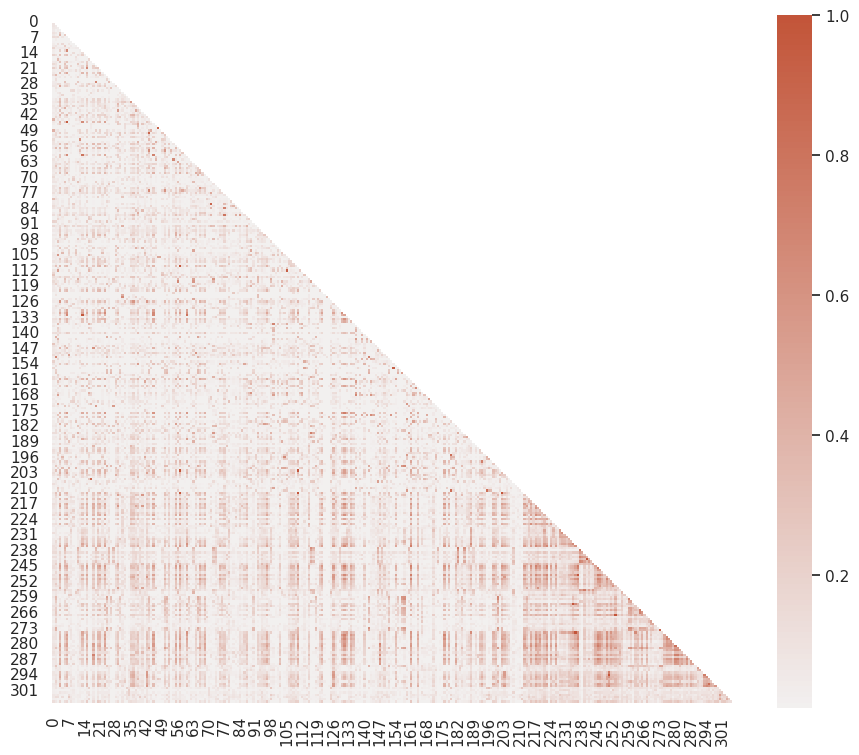

In [6]:
# Configure seaborn to set the plot style to 'white'
sns.set_theme(style="white")

# Create a mask for the upper triangle of the similarity matrix
mask = np.triu(np.ones_like(sim_df, dtype=bool))

# Create a new figure and axis for the heatmap
_, ax = plt.subplots(figsize=(11, 9))

# Create a diverging color palette for the heatmap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Plot a similarity heat map using seaborn's heatmap function
sns.heatmap(sim_df, mask=mask, cmap=cmap, vmin=0.01, vmax=1, center=0,
            square=True)


As we can see from the heatmap; there are many hot spots, which means many courses are similar to each other. Such patterns suggest that it is possible to build a recommender system based on course similarities. 


### **Load course information and BoW data**

In [7]:
# Let's first load the course content and BoW dataset
course_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_processed.csv"
course_df = pd.read_csv(course_url)
bow_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/courses_bows.csv"
bow_df = pd.read_csv(bow_url)

In [8]:
course_df.head()

,COURSE_ID,TITLE,DESCRIPTION
0,ML0201EN,robots are coming build iot apps with watson ...,have fun with iot and learn along the way if ...
1,ML0122EN,accelerating deep learning with gpu,training complex deep learning models with lar...
2,GPXX0ZG0EN,consuming restful services using the reactive ...,learn how to use a reactive jax rs client to a...
3,RP0105EN,analyzing big data in r using apache spark,apache spark is a popular cluster computing fr...
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,learn how to containerize package and run a ...


In [9]:
bow_df.head()

,doc_index,doc_id,token,bow
0,0,ML0201EN,ai,2
1,0,ML0201EN,apps,2
2,0,ML0201EN,build,2
3,0,ML0201EN,cloud,1
4,0,ML0201EN,coming,1


The matrix indices are course indices (such as `0, 1, 2, 3`).  We need to query the actual course ids (such as `ML0151EN` and `ML0101ENv3`) based on course indices and vice versa. We can save the course id's and indices into two dictionaries for late queries.

### **Create dictionaries to map course index and course ID**

Based on the `doc_index` and `doc_id` columns from `bow_df`, we create an index to id mapping and another id to index mapping in two Python dictionaries.

The `get_doc_dicts` function builds two dictionaries:

1. `idx_id_dict`

    Maps: matrix index → course ID

    Example: `200` -> `"ML0151EN"`

2. `id_idx_dict`

    Maps: course ID → matrix index

    Example: `"ML0151EN"` -> `200`


In [10]:
# Create course id to index and index to id mappings
def get_doc_dicts(bow_df):
    # Group the DataFrame by course index and ID, and get the maximum value for each group
    grouped_df = bow_df.groupby(['doc_index', 'doc_id']).max().reset_index(drop=False)
    # Create a dictionary mapping indices to course IDs
    idx_id_dict = grouped_df[['doc_id']].to_dict()['doc_id']
    # Create a dictionary mapping course IDs to indices
    id_idx_dict = {v: k for k, v in idx_id_dict.items()}
    # Clean up temporary DataFrame
    del grouped_df
    return idx_id_dict, id_idx_dict

### **Look up similarity between two example courses**

In [11]:
course1 = course_df[course_df['COURSE_ID'] == "ML0151EN"]
course1

,COURSE_ID,TITLE,DESCRIPTION
200,ML0151EN,machine learning with r,this machine learning with r course dives into...


In [12]:
course2 = course_df[course_df['COURSE_ID'] == "ML0101ENv3"]
course2

,COURSE_ID,TITLE,DESCRIPTION
158,ML0101ENv3,machine learning with python,machine learning can be an incredibly benefici...


From their titles we can see they are all about machine learning. As such, they should be very similar to each other. Let's try to find their similarity in the similarity matrix.

With their course ids, we can use the `id_idx_dict` dictionary to query their row and column index on the similarity matrix:


In [13]:
idx_id_dict, id_idx_dict = get_doc_dicts(bow_df)
idx1 = id_idx_dict["ML0151EN"]
idx2 = id_idx_dict["ML0101ENv3"]
print(f"Course 1's index is {idx1} and Course 2's index is {idx2}")

Course 1's index is 200 and Course 2's index is 158


Then we can locate their similarity value in row 200 and col 158, `sim_matrix[200][158]`:


In [14]:
## converts the DataFrame into a NumPy array and reads the similarity score directly
sim_matrix = sim_df.to_numpy()

In [15]:
sim = sim_matrix[idx1][idx2]
sim

0.6626221399549089

It's about 66% meaning these two courses are quite similar to each other.


Let's assume you are an end-user of the online course platform and already audited or completed some courses previously. Next, we expect the system would recommend similar courses based on your enrollments history.


From the full course list, choose any courses that may interest you, such as those machine learning related courses:


In [16]:
pd.set_option('display.max_rows', None)
pd.set_option('max_colwidth', None)
course_df[['COURSE_ID', 'TITLE']].head()

,COURSE_ID,TITLE
0,ML0201EN,robots are coming build iot apps with watson swift and node red
1,ML0122EN,accelerating deep learning with gpu
2,GPXX0ZG0EN,consuming restful services using the reactive jax rs client
3,RP0105EN,analyzing big data in r using apache spark
4,GPXX0Z2PEN,containerizing packaging and running a spring boot application


In [17]:
# Reset pandas settings
pd.reset_option('display.max_rows')
pd.reset_option('max_colwidth')

_TODO: Browse the course list and choose your interested courses_ 


### **Choose courses a user has already enrolled in**

In [18]:
enrolled_course_ids = ['ML0101ENv3','BD0145EN','PA0107EN'] # add your interested coures id to the list

In [19]:
enrolled_courses = course_df[course_df['COURSE_ID'].isin(enrolled_course_ids)]
enrolled_courses

,COURSE_ID,TITLE,DESCRIPTION
18,BD0145EN,sql access for hadoop,big sql is another tool to work with your hado...
30,PA0107EN,predicting financial performance of a company,predict financial performance of a company usi...
158,ML0101ENv3,machine learning with python,machine learning can be an incredibly benefici...


### **Find courses the user has not selected**
Given the full course list, we can find those unselected courses:


In [20]:
## every course in the platform
all_courses = set(course_df['COURSE_ID'])

In [21]:
## courses the user has not already taken
unselected_course_ids = all_courses.difference(enrolled_course_ids)

Now, you can iterate each unselect course and check if it is similar enough to any of your selected courses. If the similarity is larger than a threshold such as 0.5 or 0.6, then add it to your course recommendation list:


### **Main recommendation logic for one user**
- Compare all unseen courses to enrolled courses
- Keep unseen courses whose similarity is above threshold

_TODO: Complete the following method to recommend courses which are similar to one user enrolled courses_


In [22]:
def generate_recommendations_for_one_user(enrolled_course_ids, unselected_course_ids, id_idx_dict, sim_matrix):
    # Create a dictionary to store recommendation results
    res = {}
    # Set a threshold for similarity
    threshold = 0.6 
    # Iterate over enrolled courses
    for enrolled_course in enrolled_course_ids:
        # Iterate over unselected courses
        for unselect_course in unselected_course_ids:
            # Check if both enrolled and unselected courses exist in the id_idx_dict
            if enrolled_course in id_idx_dict and unselect_course in id_idx_dict:
                # Initialize similarity value
                sim = 0
                # Find the two indices for each enrolled_course and unselect_course, based on their two ids
                # Calculate the similarity between an enrolled_course and an unselect_course
                # e.g., Course ML0151EN's index is 200 and Course ML0101ENv3's index is 158
                
                # Find the similarity value from the sim_matrix
                # sim = sim_matrix[200][158]
                sim = sim_matrix[id_idx_dict[unselect_course]][id_idx_dict[enrolled_course]]
                 # Check if the similarity exceeds the threshold
                if sim > threshold:
                    # Update recommendation dictionary with course ID and similarity score
                    if unselect_course not in res:
                        # If the unselected course is not already in the recommendation dictionary (`res`), add it.
                        res[unselect_course] = sim
                    else:
                        # If the unselected course is already in the recommendation dictionary (`res`), compare the similarity score.
                        # If the current similarity score is greater than or equal to the existing similarity score for the course,
                        # update the similarity score in the recommendation dictionary (`res`) with the current similarity score.
                        if sim >= res[unselect_course]:
                            res[unselect_course] = sim
                            
    # Sort the results by similarity
    res = {k: v for k, v in sorted(res.items(), key=lambda item: item[1], reverse=True)}
     # Return the recommendation dictionary
    return res

In [23]:
generate_recommendations_for_one_user(enrolled_course_ids, unselected_course_ids, id_idx_dict, sim_matrix)

{'excourse72': 0.7036476305124202,
 'ML0151EN': 0.6626221399549089,
 'excourse47': 0.6347547807096177,
 'BD0101EN': 0.623543584505046,
 'excourse46': 0.6120541193300345}

<details>
    <summary>Click here for Hints</summary>
    
You can find the indices of the courses by using `id_idx_dict` dictionary, for example `id_idx_dict[enrolled_course]`. Then use `sim_matrix` to find the similarity of the courses as was shown earlier in the lab. 
    


The completed `generate_recommendations_user(...)` may ouput a dictionary like this:


{'ML0151EN': 0.6626221399549089,
 'excourse47': 0.6347547807096177,
 'excourse46': 0.6120541193300345}


### **Load test users**

In the previous task, you made some recommendations for yourself. Next, let's try to make recommendations for all the test users in the test dataset.


In [24]:
#test_users_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv"
test_users_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/rs_content_test.csv"
test_users_df = pd.read_csv(test_users_url)

Let's look at how many test users we have in the dataset.


In [25]:
test_users = test_users_df.groupby(['user']).max().reset_index(drop=False)
test_user_ids = test_users['user'].to_list()
print(f"Total numbers of test users {len(test_user_ids)}")

Total numbers of test users 1000


### **Recommendation logic for all users**
_TODO: Complete the ``generate_recommendations_for_all()`` method to generate recommendations for all users. You may implement the task with different solutions_


In [26]:
def generate_recommendations_for_all():
    users = [] ## user IDs
    courses = [] ## recommended course IDs
    sim_scores = [] ## recommendation scores
    # Course similarity matrix
    sim_df = pd.read_csv(sim_url)
    sim_matrix = sim_df.to_numpy()
    # Course content dataframe
    course_df = pd.read_csv(course_url)
    all_courses = set(course_df['COURSE_ID'])
    # Course BoW features
    bow_df = pd.read_csv(bow_url)
    idx_id_dict, id_idx_dict = get_doc_dicts(bow_df)
    # Test user dataframe
    test_users = test_users_df.groupby(['user']).max().reset_index(drop=False)
    test_user_ids = test_users['user'].to_list()
    
    ## for each user
    for user_id in test_user_ids: 
        # Get the known course ids for the current user
        enrolled_course_ids = test_users_df[test_users_df['user'] == user_id]['item'].to_list()
        
        # Calculate the unselected course ids  for the current user
        unselected_course_ids = all_courses.difference(enrolled_course_ids)

        # For each user, call generate_recommendations_for_one_user() to generate the recommendation results
        rec_dict = generate_recommendations_for_one_user(
            enrolled_course_ids, 
            unselected_course_ids, 
            id_idx_dict, 
            sim_matrix
        )
        # Save the result to courses, sim_scores list
        for course_id, score in rec_dict.items():
            users.append(user_id)
            courses.append(course_id)
            sim_scores.append(score)
    
    return users, courses, sim_scores

<details>
    <summary>Click here for Hints</summary>
    
Note that you can use `generate_recommendations_for_one_user` function to find the list of recommended courses for each user. Find the `enrolled_course_ids` list by simply finding them in the `test_users` list by running `test_users[test_users['user']==user_id]['item']` and to find the unselected courses list you can apply `all_courses.difference()` with `enrolled_course_ids` as it's parameter (as done earlier in the lab). (Keep the last 2 parameters of `generate_recommendations_for_one_user` the same)
</details>


### **Build the final recommendation table**

After we completed the `generate_recommendations_for_all()` function, we can call it to save the results into a dataframe:


In [27]:
res_dict = {}
users, courses, sim_scores = generate_recommendations_for_all()
res_dict['USER'] = users
res_dict['COURSE_ID'] = courses
res_dict['SCORE'] = sim_scores
res_df = pd.DataFrame(res_dict, columns=['USER', 'COURSE_ID', 'SCORE'])
res_df

,USER,COURSE_ID,SCORE
0,37465,DS0110EN,0.732941
1,37465,excourse67,0.708214
2,37465,excourse63,0.694563
3,37465,excourse72,0.652535
4,37465,excourse74,0.650071
...,...,...,...
11372,2087663,excourse28,0.623754
11373,2087663,BD0145EN,0.623544
11374,2087663,excourse68,0.616759
11375,2087663,excourse60,0.615568


Similar to the previous user profile and course genre lab, with the recommendations generated for each user, we need to write some extra analytic code to answer the following questions:


- On average, how many new/unseen courses have been recommended to each user?
- What are the most frequently recommended courses? Return the top-10 commonly recommended courses across all users?


For example, suppose we have only 3 test users, each user receives the following recommendations:


- User1: ['course1', 'course2']
- User2: ['course3', 'course4']
- User3: ['course3', 'course4', 'course5']


Then, the average recommended courses per user is $(2 + 2 + 3) / 3 = 2.33$. The top-2 recommended courses are: `course3`: 2 times, and `course4`: 2 times.


Note that the answers may depend on your similarity threshold (default is 0.6). A lower similarity threshold yields more recommended courses but with smaller irrelevance.

Ideally, we should limit the maximum course recommendations for each user to be less than 20 courses per user.


### **Calculate the average number of new courses recommended per test user**

In [28]:
# Calculate the average number of recommended courses per test user
# all test users, including those with zero recommendations and not in res_df
all_test_users = test_users_df['user'].unique()
recommendation_counts = res_df.groupby('USER')['COURSE_ID'].nunique()
# Rebuild the Series using the full list of users
# If a user is missing, fill with 0
recommendation_counts = recommendation_counts.reindex(all_test_users, fill_value=0)

# Print the result
average_courses_per_user = recommendation_counts.mean()
print("Average number of new courses recommended per test user:", average_courses_per_user)

Average number of new courses recommended per test user: 11.377


### **Determine the most frequently recommended courses across all test users**

In [29]:
# Find the top 10 most frequently recommended courses
top_10_courses = res_df.groupby('COURSE_ID').size().sort_values(ascending=False)[:10]

# Print the result with added column description
print("Top 10 most frequently recommended courses:")
print(top_10_courses)

Top 10 most frequently recommended courses:
COURSE_ID
excourse22    579
excourse62    579
DS0110EN      562
excourse65    555
excourse63    555
excourse72    551
excourse68    550
excourse74    539
excourse67    539
BD0145EN      506
dtype: int64


## **Authors**


[Yan Luo]((https://www.linkedin.com/in/yan-luo-96288783/), Su Wu


Copyright © 2021 IBM Corporation. All rights reserved.
